# Window Size Evaluation: w = 2s to 40s

Evaluates how window size affects RF head movement classifier accuracy on the test set.

**Test songs:** highway_to_hell, closer, heat_waves, cardigan, thinking_out_loud  
**Val songs:** bohemian, gods_plan, i_will_always_love_you, APT, what_a_wonderful_world

**Annotation segment lengths:** avg 15–48s, max 110s → testing up to 40s covers the meaningful range.

In [45]:
import pandas as pd
import numpy as np
import librosa
import joblib
import os
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
BASE_DIR   = '/Users/miaaa/Desktop/music robot/furhat_music_robot'
AUDIO_DIR  = os.path.join(BASE_DIR, 'train')
ANN_DIR    = os.path.join(BASE_DIR, 'annotations')
MODELS_DIR = os.path.join(BASE_DIR, 'models')

rf           = joblib.load(os.path.join(MODELS_DIR, 'head_classifier.pkl'))
scaler       = joblib.load(os.path.join(MODELS_DIR, 'head_scaler.pkl'))
feature_cols = joblib.load(os.path.join(MODELS_DIR, 'head_feature_cols.pkl'))

print('RF classes:', rf.classes_)
print('Feature count:', len(feature_cols))

RF classes: ['nod' 'none' 'shake' 'sway']
Feature count: 111


In [47]:
def extract_features(segment, sr):
    features = {}
    mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f'mfcc_{i+1}_mean'] = float(np.mean(mfcc[i]))
        features[f'mfcc_{i+1}_std']  = float(np.std(mfcc[i]))
    mfcc_delta = librosa.feature.delta(mfcc)
    for i in range(13):
        features[f'mfcc_delta_{i+1}_mean'] = float(np.mean(mfcc_delta[i]))
        features[f'mfcc_delta_{i+1}_std']  = float(np.std(mfcc_delta[i]))
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
    for i in range(13):
        features[f'mfcc_delta2_{i+1}_mean'] = float(np.mean(mfcc_delta2[i]))
        features[f'mfcc_delta2_{i+1}_std']  = float(np.std(mfcc_delta2[i]))
    chroma = librosa.feature.chroma_stft(y=segment, sr=sr)
    for i in range(12):
        features[f'chroma_{i+1}_mean'] = float(np.mean(chroma[i]))
        features[f'chroma_{i+1}_std']  = float(np.std(chroma[i]))
    rms = librosa.feature.rms(y=segment)
    features['rms_mean'] = float(np.mean(rms))
    features['rms_std']  = float(np.std(rms))
    centroid = librosa.feature.spectral_centroid(y=segment, sr=sr)
    features['spectral_centroid_mean'] = float(np.mean(centroid))
    features['spectral_centroid_std']  = float(np.std(centroid))
    bandwidth = librosa.feature.spectral_bandwidth(y=segment, sr=sr)
    features['spectral_bandwidth_mean'] = float(np.mean(bandwidth))
    features['spectral_bandwidth_std']  = float(np.std(bandwidth))
    zcr = librosa.feature.zero_crossing_rate(y=segment)
    features['zcr_mean'] = float(np.mean(zcr))
    features['zcr_std']  = float(np.std(zcr))
    tempo_result = librosa.beat.beat_track(y=segment, sr=sr)
    tempo = tempo_result[0] if isinstance(tempo_result, tuple) else tempo_result
    tempo = float(tempo[0]) if isinstance(tempo, np.ndarray) else float(tempo)
    features['tempo'] = tempo
    return features


def get_ground_truth_label(window_start, window_end, ann_df):
    best_label, best_overlap = None, 0.0
    for _, row in ann_df.iterrows():
        overlap = max(0, min(window_end, row['end_time']) - max(window_start, row['start_time']))
        if overlap > best_overlap:
            best_overlap = overlap
            best_label = str(row['head movement']).strip()
    return best_label


def evaluate_song(song_name, window_size):
    audio_path = os.path.join(AUDIO_DIR, f'{song_name}.wav')
    ann_path   = os.path.join(ANN_DIR,   f'{song_name}.csv')
    if not os.path.exists(audio_path):
        print(f'  SKIP {song_name}: audio not found')
        return []
    y, sr = librosa.load(audio_path, sr=None)
    duration = len(y) / sr
    ann_df = pd.read_csv(ann_path)
    results = []
    window_start = 0.0
    while window_start + window_size <= duration:
        window_end = window_start + window_size
        segment = y[int(window_start * sr):int(window_end * sr)]
        feats = extract_features(segment, sr)
        X_scaled = scaler.transform(np.array([[feats[c] for c in feature_cols]]))
        pred = rf.predict(X_scaled)[0]
        true_label = get_ground_truth_label(window_start, window_end, ann_df)
        if true_label is not None:
            results.append({'song': song_name, 'start': window_start,
                            'true': true_label, 'pred': pred})
        window_start = window_end
    return results

In [48]:
TEST_SONGS = ['highway_to_hell', 'closer', 'heat_waves', 'cardigan', 'thinking_out_loud']
VAL_SONGS  = ['bohemian', 'gods_plan', 'i_will_always_love_you', 'APT', 'what_a_wonderful_world']

TARGET_LABELS = ['nod', 'none', 'shake', 'sway']
MERGE_MAP = {'shake, nod': 'nod', 'sway, nod': 'sway',
             'look down': 'none', 'look up': 'none'}

# 2-10s every 1s, then coarser
WINDOW_SIZES = list(range(2, 11)) + [12, 15, 20, 25, 30, 40]

def run_eval(songs, label):
    results = {}
    for w in WINDOW_SIZES:
        rows = []
        for song in songs:
            rows.extend(evaluate_song(song, float(w)))
        df = pd.DataFrame(rows)
        df['true'] = df['true'].replace(MERGE_MAP)
        df = df[df['true'].isin(TARGET_LABELS)]
        results[w] = df
        acc = accuracy_score(df['true'], df['pred'])
        print(f'  w={w:>2}s  n={len(df):>4}  acc={acc:.4f}')
    return results

print('=== Test Set ===')
results_test = run_eval(TEST_SONGS, 'test')
print('\n=== Validation Set ===')
results_val = run_eval(VAL_SONGS, 'val')
print('\nDone.')

=== Test Set ===
  w= 2s  n= 604  acc=0.3113
  w= 3s  n= 401  acc=0.3267
  w= 4s  n= 301  acc=0.3588
  w= 5s  n= 239  acc=0.3849
  w= 6s  n= 198  acc=0.4040
  w= 7s  n= 171  acc=0.4211
  w= 8s  n= 149  acc=0.4362
  w= 9s  n= 133  acc=0.4211
  w=10s  n= 118  acc=0.3983
  w=12s  n=  98  acc=0.4490
  w=15s  n=  77  acc=0.4805
  w=20s  n=  58  acc=0.4655
  w=25s  n=  46  acc=0.3696
  w=30s  n=  37  acc=0.3784
  w=40s  n=  28  acc=0.4643

=== Validation Set ===


/Users/miaaa/Desktop/music robot/furhat_music_robot/.venv/lib/python3.12/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


  w= 2s  n= 563  acc=0.3694
  w= 3s  n= 375  acc=0.3627
  w= 4s  n= 280  acc=0.3571
  w= 5s  n= 222  acc=0.3829
  w= 6s  n= 187  acc=0.3850
  w= 7s  n= 159  acc=0.3962
  w= 8s  n= 139  acc=0.3885
  w= 9s  n= 123  acc=0.4146
  w=10s  n= 109  acc=0.4404
  w=12s  n=  92  acc=0.3913
  w=15s  n=  73  acc=0.4658
  w=20s  n=  53  acc=0.4340
  w=25s  n=  42  acc=0.4048
  w=30s  n=  34  acc=0.3824
  w=40s  n=  25  acc=0.4000

Done.


In [49]:
# --- Summary table ---
print(f'{"w":>4}  {"Test n":>7}  {"Test acc":>9}  {"Val n":>6}  {"Val acc":>8}')
print('-' * 44)
for w in WINDOW_SIZES:
    dt = results_test[w]; dv = results_val[w]
    at = accuracy_score(dt['true'], dt['pred'])
    av = accuracy_score(dv['true'], dv['pred'])
    print(f'{w:>3}s  {len(dt):>7}  {at:>9.4f}  {len(dv):>6}  {av:>8.4f}')

   w   Test n   Test acc   Val n   Val acc
--------------------------------------------
  2s      604     0.3113     563    0.3694
  3s      401     0.3267     375    0.3627
  4s      301     0.3588     280    0.3571
  5s      239     0.3849     222    0.3829
  6s      198     0.4040     187    0.3850
  7s      171     0.4211     159    0.3962
  8s      149     0.4362     139    0.3885
  9s      133     0.4211     123    0.4146
 10s      118     0.3983     109    0.4404
 12s       98     0.4490      92    0.3913
 15s       77     0.4805      73    0.4658
 20s       58     0.4655      53    0.4340
 25s       46     0.3696      42    0.4048
 30s       37     0.3784      34    0.3824
 40s       28     0.4643      25    0.4000


In [50]:
# --- Per-song accuracy table ---
header = f'{"Song":30s}' + ''.join(f' {w:>4}s' for w in WINDOW_SIZES)
print('TEST SET')
print(header)
print('-' * len(header))
for song in TEST_SONGS:
    row_str = f'{song:30s}'
    for w in WINDOW_SIZES:
        s = results_test[w][results_test[w]['song'] == song]
        a = accuracy_score(s['true'], s['pred']) if len(s) > 0 else float('nan')
        row_str += f' {a:>5.2f}'
    print(row_str)

print('\nVALIDATION SET')
print(header)
print('-' * len(header))
for song in VAL_SONGS:
    row_str = f'{song:30s}'
    for w in WINDOW_SIZES:
        s = results_val[w][results_val[w]['song'] == song]
        a = accuracy_score(s['true'], s['pred']) if len(s) > 0 else float('nan')
        row_str += f' {a:>5.2f}'
    print(row_str)

TEST SET
Song                              2s    3s    4s    5s    6s    7s    8s    9s   10s   12s   15s   20s   25s   30s   40s
------------------------------------------------------------------------------------------------------------------------
highway_to_hell                 0.12  0.13  0.15  0.15  0.15  0.17  0.19  0.13  0.10  0.12  0.23  0.30  0.00  0.00  0.20
closer                          0.38  0.41  0.39  0.40  0.47  0.47  0.47  0.44  0.46  0.50  0.50  0.50  0.22  0.38  0.83
heat_waves                      0.61  0.66  0.59  0.64  0.67  0.59  0.62  0.65  0.57  0.68  0.73  0.55  0.67  0.57  0.60
cardigan                        0.38  0.37  0.56  0.64  0.69  0.82  0.79  0.81  0.83  0.84  0.93  1.00  0.89  1.00  0.80
thinking_out_loud               0.08  0.09  0.11  0.12  0.07  0.07  0.14  0.10  0.07  0.13  0.06  0.07  0.09  0.00  0.00

VALIDATION SET
Song                              2s    3s    4s    5s    6s    7s    8s    9s   10s   12s   15s   20s   25s   30s   40s
-------

In [51]:
# --- Classification reports (Test, key window sizes) ---
for w in [3, 5, 7, 10, 15, 20]:
    df = results_test[w]
    acc = accuracy_score(df['true'], df['pred'])
    print(f'\n=== TEST  w={w}s  acc={acc:.4f}  n={len(df)} ===')
    print(classification_report(df['true'], df['pred'], labels=TARGET_LABELS, zero_division=0))


=== TEST  w=3s  acc=0.3267  n=401 ===
              precision    recall  f1-score   support

         nod       0.54      0.46      0.50       194
        none       0.18      0.84      0.29        45
       shake       0.17      0.06      0.09        47
        sway       0.00      0.00      0.00       115

    accuracy                           0.33       401
   macro avg       0.22      0.34      0.22       401
weighted avg       0.30      0.33      0.28       401


=== TEST  w=5s  acc=0.3849  n=239 ===
              precision    recall  f1-score   support

         nod       0.53      0.62      0.57       117
        none       0.20      0.72      0.32        25
       shake       0.10      0.04      0.05        27
        sway       0.00      0.00      0.00        70

    accuracy                           0.38       239
   macro avg       0.21      0.35      0.24       239
weighted avg       0.29      0.38      0.32       239


=== TEST  w=7s  acc=0.4211  n=171 ===
             

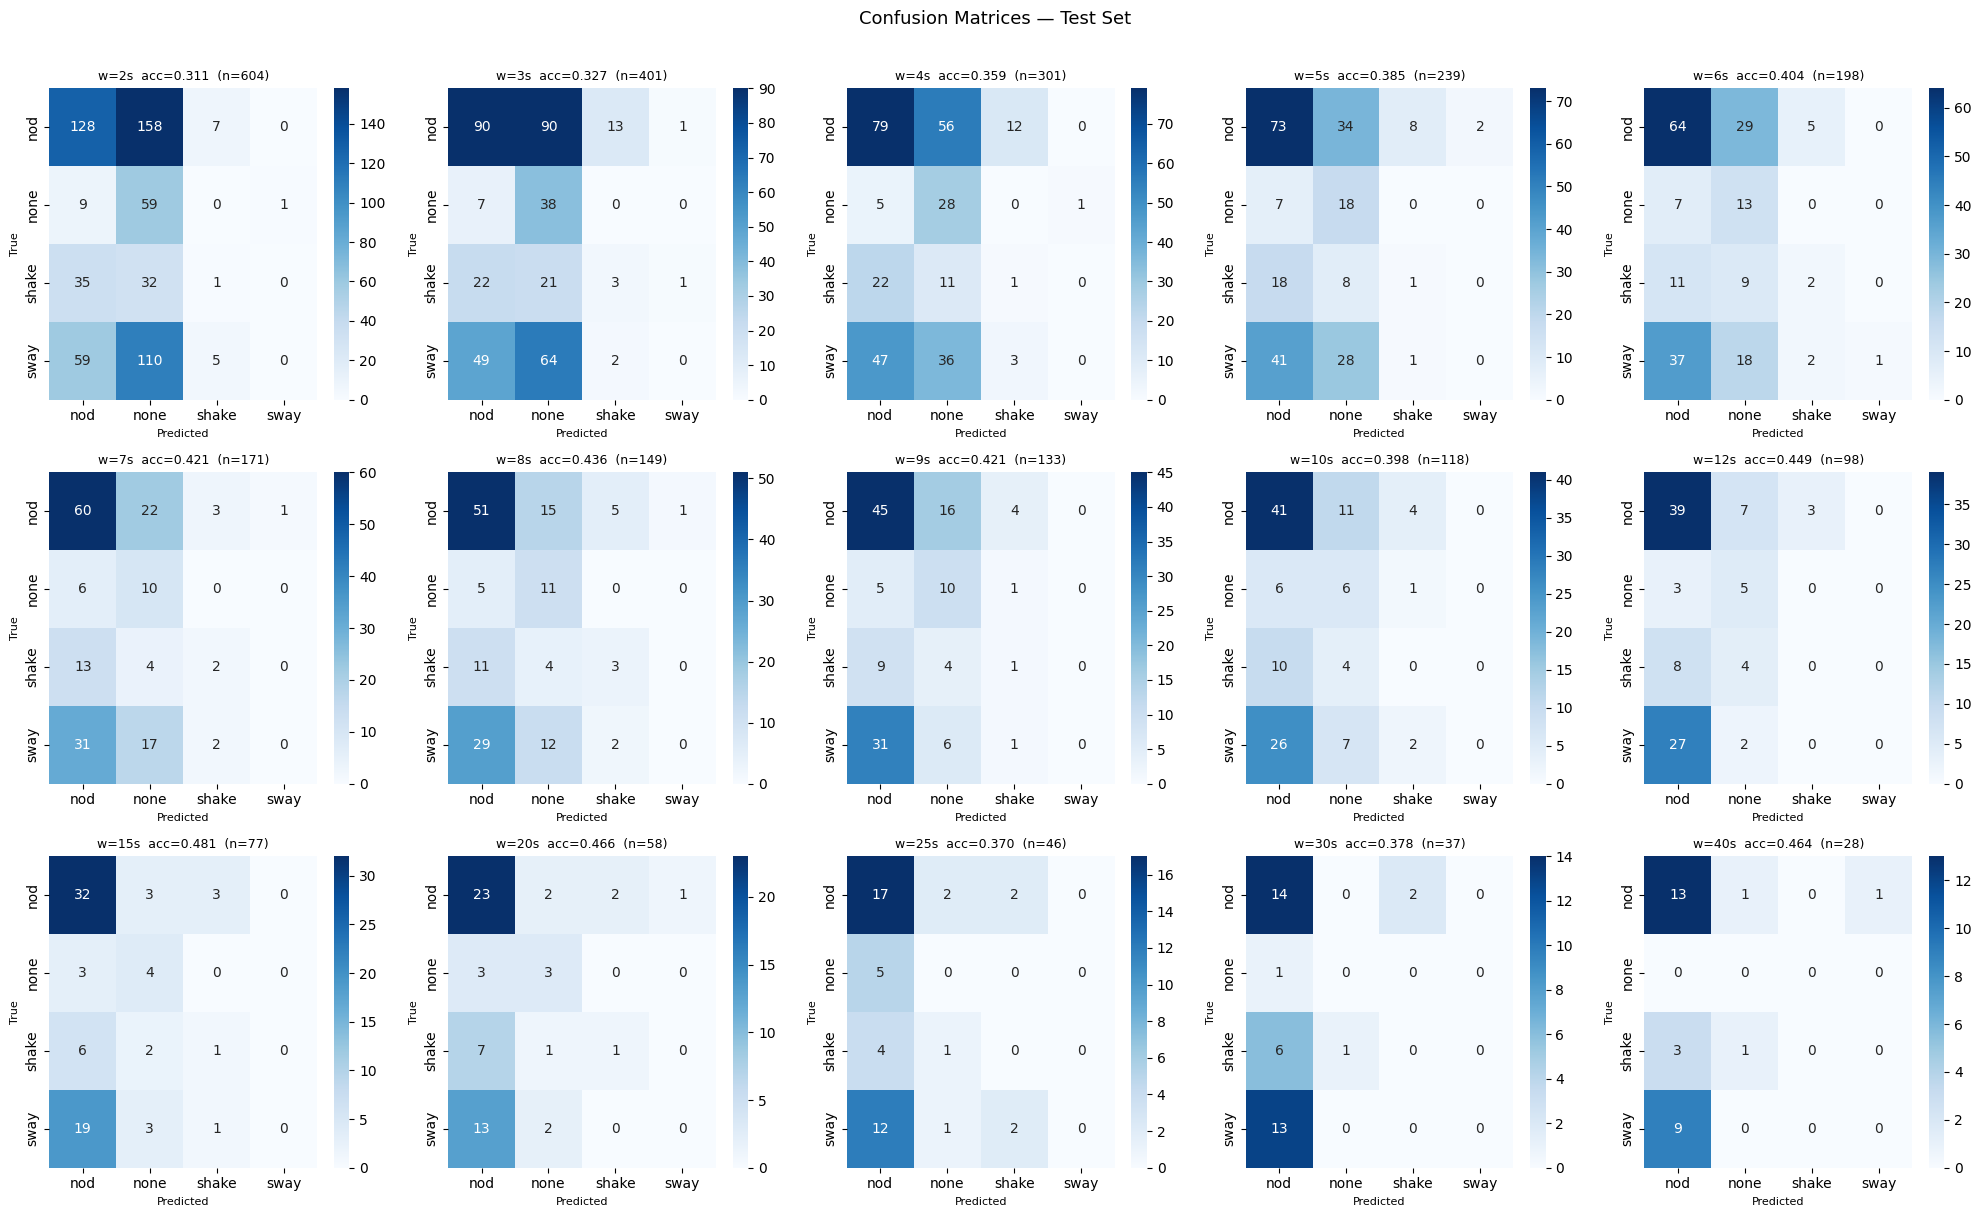

In [52]:
# --- Confusion matrices (Test set, all window sizes) ---
n_w   = len(WINDOW_SIZES)
ncols = 5
nrows = (n_w + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.flatten()

for i, w in enumerate(WINDOW_SIZES):
    df = results_test[w]
    acc = accuracy_score(df['true'], df['pred'])
    cm = confusion_matrix(df['true'], df['pred'], labels=TARGET_LABELS)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=TARGET_LABELS, yticklabels=TARGET_LABELS, ax=axes[i])
    axes[i].set_title(f'w={w}s  acc={acc:.3f}  (n={len(df)})', fontsize=9)
    axes[i].set_xlabel('Predicted', fontsize=8)
    axes[i].set_ylabel('True', fontsize=8)

for j in range(len(WINDOW_SIZES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'window_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

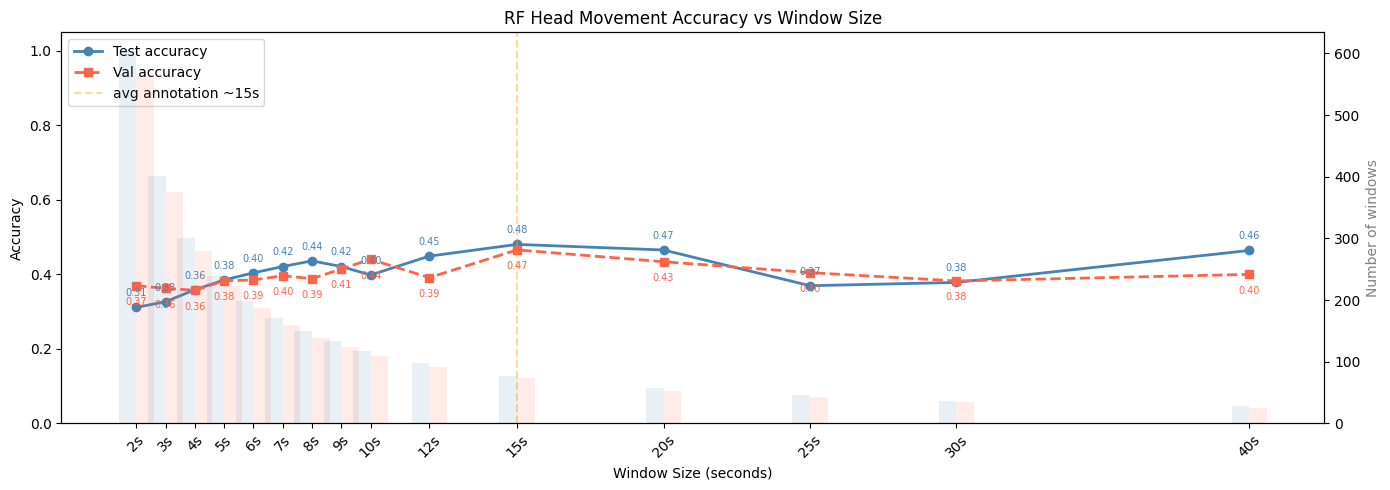

In [53]:
# --- Accuracy vs window size: Test vs Validation ---
accs_test = [accuracy_score(results_test[w]['true'], results_test[w]['pred']) for w in WINDOW_SIZES]
accs_val  = [accuracy_score(results_val[w]['true'],  results_val[w]['pred'])  for w in WINDOW_SIZES]
n_test    = [len(results_test[w]) for w in WINDOW_SIZES]
n_val     = [len(results_val[w])  for w in WINDOW_SIZES]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(WINDOW_SIZES, accs_test, 'o-',  color='steelblue', linewidth=2, markersize=6, label='Test accuracy')
ax1.plot(WINDOW_SIZES, accs_val,  's--', color='tomato',    linewidth=2, markersize=6, label='Val accuracy')
for w, at, av in zip(WINDOW_SIZES, accs_test, accs_val):
    ax1.annotate(f'{at:.2f}', (w, at), textcoords='offset points', xytext=(0,  8), ha='center', fontsize=7, color='steelblue')
    ax1.annotate(f'{av:.2f}', (w, av), textcoords='offset points', xytext=(0, -14), ha='center', fontsize=7, color='tomato')
ax1.set_xlabel('Window Size (seconds)')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(WINDOW_SIZES)
ax1.set_xticklabels([f'{w}s' for w in WINDOW_SIZES], rotation=45)
ax1.set_ylim(0, 1.05)
ax1.set_title('RF Head Movement Accuracy vs Window Size')
ax1.axvline(x=15, color='orange', linestyle='--', alpha=0.4, label='avg annotation ~15s')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar([w - 0.3 for w in WINDOW_SIZES], n_test, alpha=0.12, color='steelblue', width=0.6)
ax2.bar([w + 0.3 for w in WINDOW_SIZES], n_val,  alpha=0.12, color='tomato',    width=0.6)
ax2.set_ylabel('Number of windows', color='grey')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'window_accuracy_vs_size.png'), dpi=150)
plt.show()

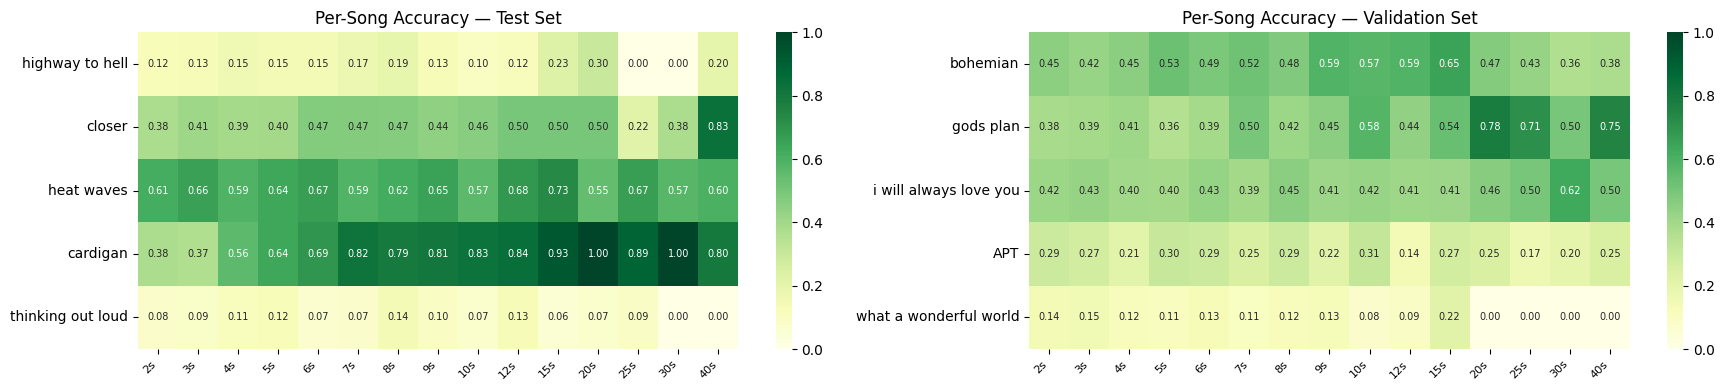

In [54]:
# --- Per-song accuracy heatmaps ---
fig, (ax_t, ax_v) = plt.subplots(1, 2, figsize=(18, 4))

for ax, songs, results, title in [
    (ax_t, TEST_SONGS, results_test, 'Test Set'),
    (ax_v, VAL_SONGS,  results_val,  'Validation Set'),
]:
    data = np.full((len(songs), len(WINDOW_SIZES)), np.nan)
    for j, w in enumerate(WINDOW_SIZES):
        df = results[w]
        for i, song in enumerate(songs):
            s = df[df['song'] == song]
            if len(s) > 0:
                data[i, j] = accuracy_score(s['true'], s['pred'])
    sns.heatmap(data, annot=True, fmt='.2f', cmap='YlGn',
                xticklabels=[f'{w}s' for w in WINDOW_SIZES],
                yticklabels=[s.replace('_', ' ') for s in songs],
                vmin=0, vmax=1, ax=ax, annot_kws={'size': 7})
    ax.set_title(f'Per-Song Accuracy — {title}')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'window_per_song_heatmap.png'), dpi=150)
plt.show()

## Interpretation

- Pick the window size where **both test and val accuracy stabilise** (not just keep rising)
- Prefer smaller windows if accuracy is close — more responsive behaviour for Furhat
- Ground truth: **max-overlap rule** — each window gets the label of the annotation segment that overlaps it most

---
# Facial Expression — HMM Window Size Evaluation

Uses the saved `facial_hmm_models.pkl` (GaussianHMM per class, 4 classes: `big_smile`, `frown`, `neutral`, `smile`).

Prediction: for each window, score against every per-class HMM and pick the highest log-likelihood.

**Same test/val split as head movement.**

In [55]:
# --- Load facial HMM models ---
facial_hmm    = joblib.load(os.path.join(MODELS_DIR, 'facial_hmm_models.pkl'))
facial_scaler = joblib.load(os.path.join(MODELS_DIR, 'facial_hmm_scaler.pkl'))
facial_feat_cols = joblib.load(os.path.join(MODELS_DIR, 'facial_hmm_feature_cols.pkl'))

FACIAL_CLASSES = list(facial_hmm.keys())
print('Facial HMM classes:', FACIAL_CLASSES)
print('Feature count:', len(facial_feat_cols))

Facial HMM classes: ['big_smile', 'frown', 'neutral', 'smile']
Feature count: 50


In [56]:
FACIAL_MERGE_MAP = {
    'negative': 'frown',
    'thoughtful': 'neutral',
    'big smile': 'big_smile',
}
FACIAL_TARGET_LABELS = FACIAL_CLASSES  # ['big_smile', 'frown', 'neutral', 'smile']


def predict_hmm(features_dict):
    """Score a single feature vector against all per-class HMMs; return best class."""
    X = np.array([[features_dict[c] for c in facial_feat_cols]])
    X_scaled = facial_scaler.transform(X)
    scores = {cls: facial_hmm[cls].score(X_scaled) for cls in FACIAL_CLASSES}
    return max(scores, key=scores.get)


def get_facial_ground_truth(window_start, window_end, ann_df):
    best_label, best_overlap = None, 0.0
    for _, row in ann_df.iterrows():
        overlap = max(0, min(window_end, row['end_time']) - max(window_start, row['start_time']))
        if overlap > best_overlap:
            best_overlap = overlap
            best_label = str(row['facial expression']).strip()
    return best_label


def evaluate_facial_song(song_name, window_size):
    audio_path = os.path.join(AUDIO_DIR, f'{song_name}.wav')
    ann_path   = os.path.join(ANN_DIR,   f'{song_name}.csv')
    if not os.path.exists(audio_path):
        print(f'  SKIP {song_name}: audio not found')
        return []
    y, sr = librosa.load(audio_path, sr=None)
    duration = len(y) / sr
    ann_df = pd.read_csv(ann_path)
    results = []
    window_start = 0.0
    while window_start + window_size <= duration:
        window_end = window_start + window_size
        segment = y[int(window_start * sr):int(window_end * sr)]
        feats = extract_features(segment, sr)  # reuse head feature extractor (same 78 feats, take subset)
        pred = predict_hmm(feats)
        true_label = get_facial_ground_truth(window_start, window_end, ann_df)
        if true_label is not None:
            results.append({'song': song_name, 'start': window_start,
                            'true': true_label, 'pred': pred})
        window_start = window_end
    return results

In [57]:
def run_facial_eval(songs):
    results = {}
    for w in WINDOW_SIZES:
        rows = []
        for song in songs:
            rows.extend(evaluate_facial_song(song, float(w)))
        df = pd.DataFrame(rows)
        df['true'] = df['true'].replace(FACIAL_MERGE_MAP)
        df = df[df['true'].isin(FACIAL_TARGET_LABELS)]
        results[w] = df
        acc = accuracy_score(df['true'], df['pred'])
        print(f'  w={w:>2}s  n={len(df):>4}  acc={acc:.4f}')
    return results

print('=== Facial — Test Set ===')
facial_results_test = run_facial_eval(TEST_SONGS)
print('\n=== Facial — Validation Set ===')
facial_results_val = run_facial_eval(VAL_SONGS)
print('\nDone.')

=== Facial — Test Set ===
  w= 2s  n= 507  acc=0.3570
  w= 3s  n= 336  acc=0.3661
  w= 4s  n= 253  acc=0.3794
  w= 5s  n= 200  acc=0.3500
  w= 6s  n= 167  acc=0.3832
  w= 7s  n= 144  acc=0.3819
  w= 8s  n= 125  acc=0.3600
  w= 9s  n= 111  acc=0.3874
  w=10s  n=  99  acc=0.3737
  w=12s  n=  84  acc=0.3810
  w=15s  n=  66  acc=0.4091
  w=20s  n=  52  acc=0.3846
  w=25s  n=  39  acc=0.3590
  w=30s  n=  31  acc=0.2581
  w=40s  n=  23  acc=0.3478

=== Facial — Validation Set ===


/Users/miaaa/Desktop/music robot/furhat_music_robot/.venv/lib/python3.12/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


  w= 2s  n= 438  acc=0.2922
  w= 3s  n= 293  acc=0.3413
  w= 4s  n= 219  acc=0.3288
  w= 5s  n= 171  acc=0.3216
  w= 6s  n= 144  acc=0.3333
  w= 7s  n= 124  acc=0.3387
  w= 8s  n= 105  acc=0.3048
  w= 9s  n=  96  acc=0.3333
  w=10s  n=  85  acc=0.3412
  w=12s  n=  72  acc=0.3611
  w=15s  n=  57  acc=0.3509
  w=20s  n=  42  acc=0.3571
  w=25s  n=  33  acc=0.4242
  w=30s  n=  26  acc=0.3462
  w=40s  n=  20  acc=0.2000

Done.


In [58]:
# --- Summary table ---
print(f'{'w':>4}  {'Test n':>7}  {'Test acc':>9}  {'Val n':>6}  {'Val acc':>8}')
print('-' * 44)
for w in WINDOW_SIZES:
    dt = facial_results_test[w]; dv = facial_results_val[w]
    at = accuracy_score(dt['true'], dt['pred'])
    av = accuracy_score(dv['true'], dv['pred'])
    print(f'{w:>3}s  {len(dt):>7}  {at:>9.4f}  {len(dv):>6}  {av:>8.4f}')

   w   Test n   Test acc   Val n   Val acc
--------------------------------------------
  2s      507     0.3570     438    0.2922
  3s      336     0.3661     293    0.3413
  4s      253     0.3794     219    0.3288
  5s      200     0.3500     171    0.3216
  6s      167     0.3832     144    0.3333
  7s      144     0.3819     124    0.3387
  8s      125     0.3600     105    0.3048
  9s      111     0.3874      96    0.3333
 10s       99     0.3737      85    0.3412
 12s       84     0.3810      72    0.3611
 15s       66     0.4091      57    0.3509
 20s       52     0.3846      42    0.3571
 25s       39     0.3590      33    0.4242
 30s       31     0.2581      26    0.3462
 40s       23     0.3478      20    0.2000


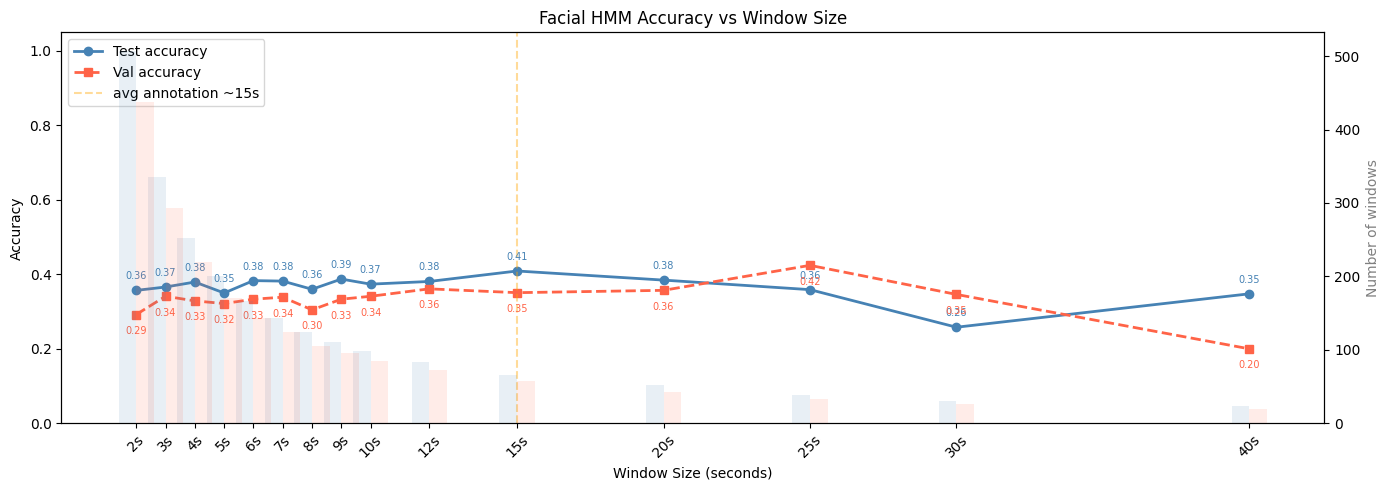

In [59]:
# --- Accuracy vs window size: Facial HMM ---
accs_f_test = [accuracy_score(facial_results_test[w]['true'], facial_results_test[w]['pred']) for w in WINDOW_SIZES]
accs_f_val  = [accuracy_score(facial_results_val[w]['true'],  facial_results_val[w]['pred'])  for w in WINDOW_SIZES]
n_f_test    = [len(facial_results_test[w]) for w in WINDOW_SIZES]
n_f_val     = [len(facial_results_val[w])  for w in WINDOW_SIZES]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(WINDOW_SIZES, accs_f_test, 'o-',  color='steelblue', linewidth=2, markersize=6, label='Test accuracy')
ax1.plot(WINDOW_SIZES, accs_f_val,  's--', color='tomato',    linewidth=2, markersize=6, label='Val accuracy')
for w, at, av in zip(WINDOW_SIZES, accs_f_test, accs_f_val):
    ax1.annotate(f'{at:.2f}', (w, at), textcoords='offset points', xytext=(0,  8), ha='center', fontsize=7, color='steelblue')
    ax1.annotate(f'{av:.2f}', (w, av), textcoords='offset points', xytext=(0, -14), ha='center', fontsize=7, color='tomato')
ax1.set_xlabel('Window Size (seconds)')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(WINDOW_SIZES)
ax1.set_xticklabels([f'{w}s' for w in WINDOW_SIZES], rotation=45)
ax1.set_ylim(0, 1.05)
ax1.set_title('Facial HMM Accuracy vs Window Size')
ax1.axvline(x=15, color='orange', linestyle='--', alpha=0.4, label='avg annotation ~15s')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar([w - 0.3 for w in WINDOW_SIZES], n_f_test, alpha=0.12, color='steelblue', width=0.6)
ax2.bar([w + 0.3 for w in WINDOW_SIZES], n_f_val,  alpha=0.12, color='tomato',    width=0.6)
ax2.set_ylabel('Number of windows', color='grey')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'facial_window_accuracy_vs_size.png'), dpi=150)
plt.show()

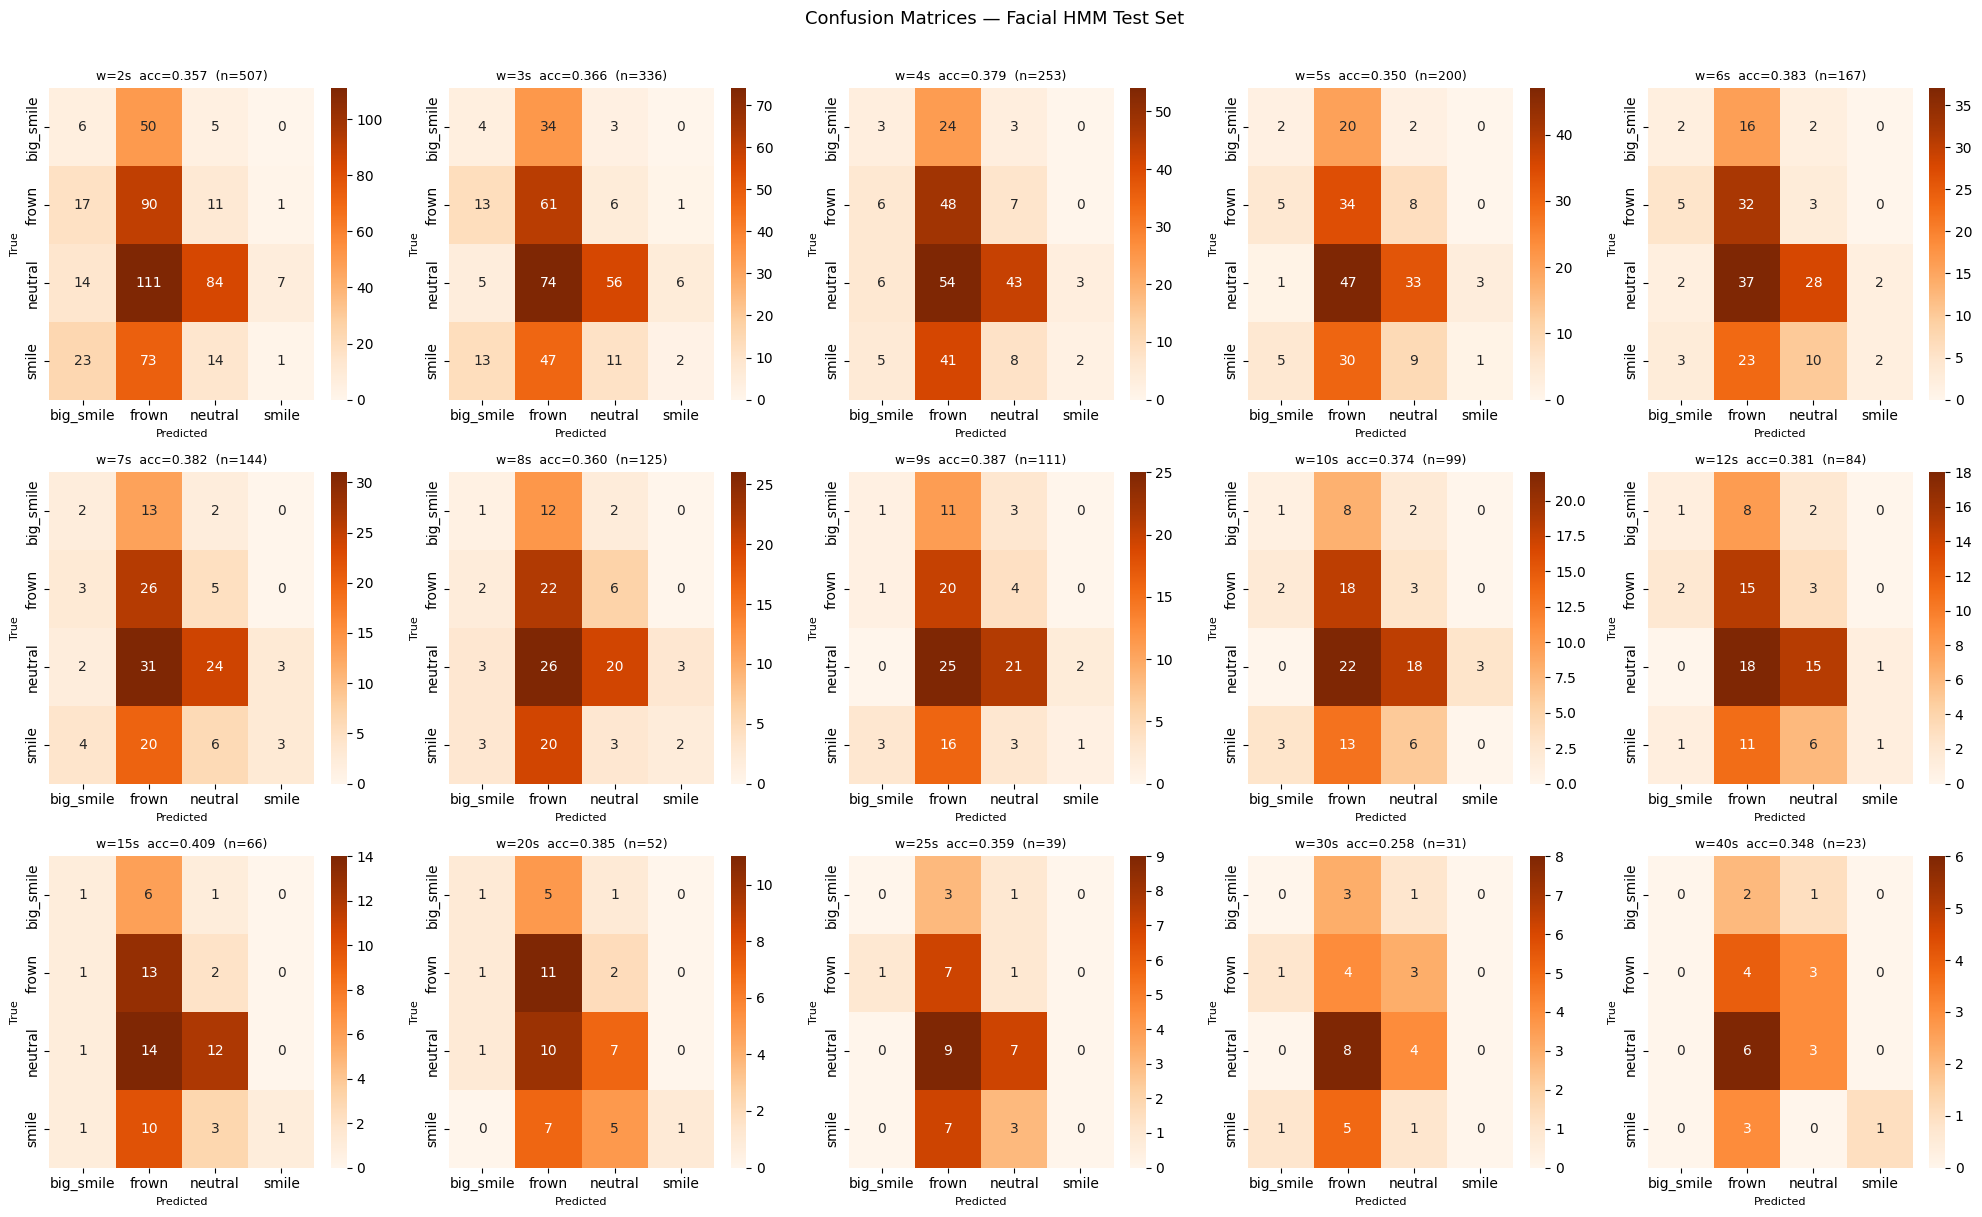

In [60]:
# --- Confusion matrices (Test set, all window sizes) ---
n_w   = len(WINDOW_SIZES)
ncols = 5
nrows = (n_w + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.flatten()

for i, w in enumerate(WINDOW_SIZES):
    df = facial_results_test[w]
    acc = accuracy_score(df['true'], df['pred'])
    cm = confusion_matrix(df['true'], df['pred'], labels=FACIAL_TARGET_LABELS)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=FACIAL_TARGET_LABELS, yticklabels=FACIAL_TARGET_LABELS, ax=axes[i])
    axes[i].set_title(f'w={w}s  acc={acc:.3f}  (n={len(df)})', fontsize=9)
    axes[i].set_xlabel('Predicted', fontsize=8)
    axes[i].set_ylabel('True', fontsize=8)

for j in range(len(WINDOW_SIZES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — Facial HMM Test Set', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'facial_window_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

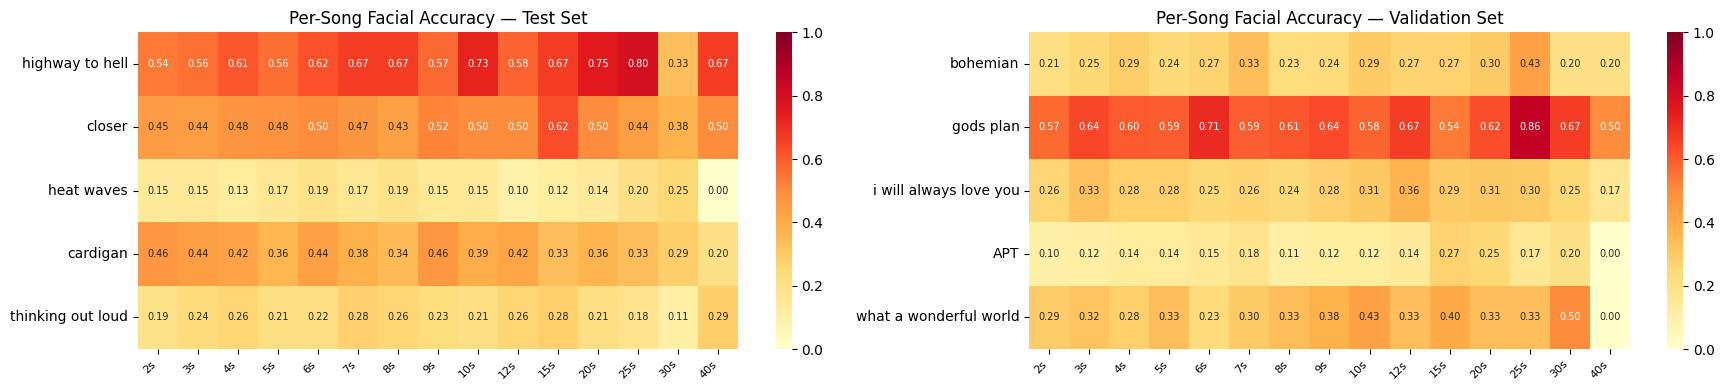

In [61]:
# --- Per-song accuracy heatmaps ---
fig, (ax_t, ax_v) = plt.subplots(1, 2, figsize=(18, 4))

for ax, songs, results, title in [
    (ax_t, TEST_SONGS, facial_results_test, 'Test Set'),
    (ax_v, VAL_SONGS,  facial_results_val,  'Validation Set'),
]:
    data = np.full((len(songs), len(WINDOW_SIZES)), np.nan)
    for j, w in enumerate(WINDOW_SIZES):
        df = results[w]
        for i, song in enumerate(songs):
            s = df[df['song'] == song]
            if len(s) > 0:
                data[i, j] = accuracy_score(s['true'], s['pred'])
    sns.heatmap(data, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=[f'{w}s' for w in WINDOW_SIZES],
                yticklabels=[s.replace('_', ' ') for s in songs],
                vmin=0, vmax=1, ax=ax, annot_kws={'size': 7})
    ax.set_title(f'Per-Song Facial Accuracy — {title}')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'facial_window_per_song_heatmap.png'), dpi=150)
plt.show()

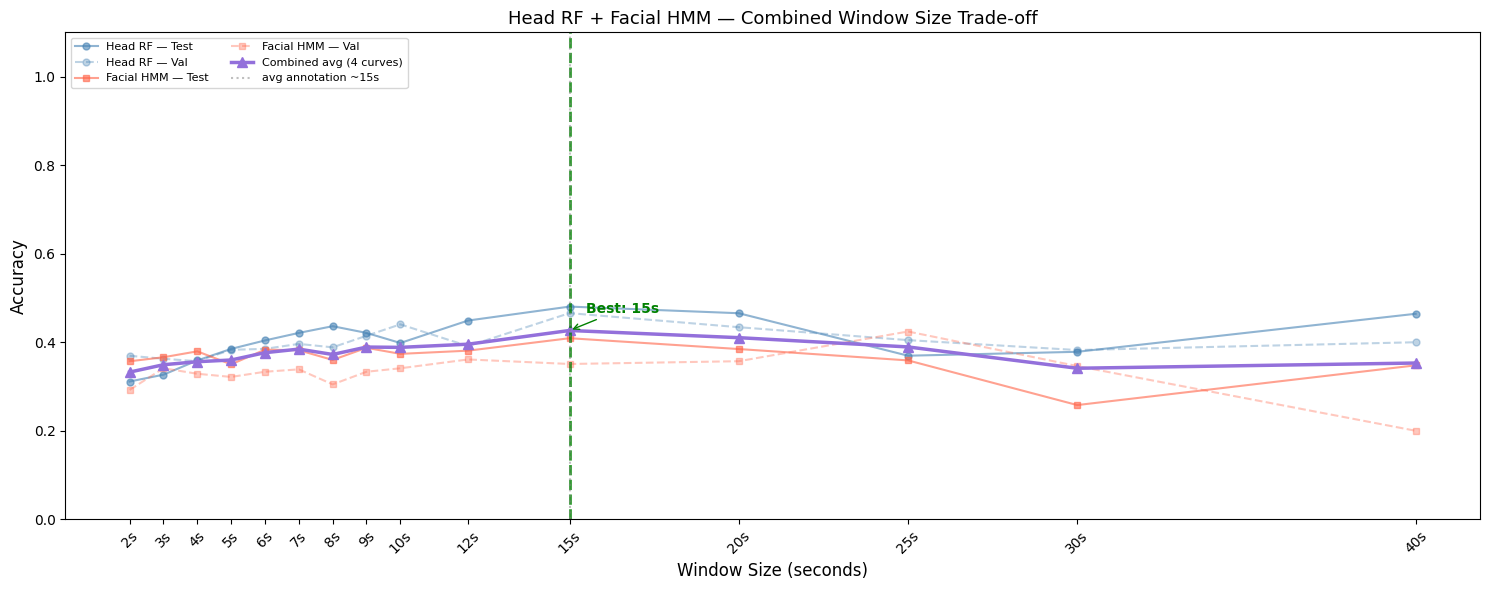

   w   Head-T   Head-V   Face-T   Face-V   AvgAcc
--------------------------------------------------
  2s   0.3113   0.3694   0.3570   0.2922   0.3325
  3s   0.3267   0.3627   0.3661   0.3413   0.3492
  4s   0.3588   0.3571   0.3794   0.3288   0.3560
  5s   0.3849   0.3829   0.3500   0.3216   0.3599
  6s   0.4040   0.3850   0.3832   0.3333   0.3764
  7s   0.4211   0.3962   0.3819   0.3387   0.3845
  8s   0.4362   0.3885   0.3600   0.3048   0.3724
  9s   0.4211   0.4146   0.3874   0.3333   0.3891
 10s   0.3983   0.4404   0.3737   0.3412   0.3884
 12s   0.4490   0.3913   0.3810   0.3611   0.3956
 15s   0.4805   0.4658   0.4091   0.3509   0.4266 <-- best
 20s   0.4655   0.4340   0.3846   0.3571   0.4103
 25s   0.3696   0.4048   0.3590   0.4242   0.3894
 30s   0.3784   0.3824   0.2581   0.3462   0.3412
 40s   0.4643   0.4000   0.3478   0.2000   0.3530


In [63]:
# --- Combined: Head RF + Facial HMM — find best trade-off window size ---

accs_head_test = [accuracy_score(results_test[w]['true'], results_test[w]['pred']) for w in WINDOW_SIZES]
accs_head_val  = [accuracy_score(results_val[w]['true'],  results_val[w]['pred'])  for w in WINDOW_SIZES]
accs_face_test = [accuracy_score(facial_results_test[w]['true'], facial_results_test[w]['pred']) for w in WINDOW_SIZES]
accs_face_val  = [accuracy_score(facial_results_val[w]['true'],  facial_results_val[w]['pred'])  for w in WINDOW_SIZES]

# Average across both tasks and both splits → one combined score per window
avg_acc = [(h_t + h_v + f_t + f_v) / 4
           for h_t, h_v, f_t, f_v in
           zip(accs_head_test, accs_head_val, accs_face_test, accs_face_val)]

best_idx = avg_acc.index(max(avg_acc))
best_w   = WINDOW_SIZES[best_idx]

fig, ax = plt.subplots(figsize=(15, 6))

# Individual lines
ax.plot(WINDOW_SIZES, accs_head_test, 'o-',  color='steelblue',  alpha=0.6, linewidth=1.5, markersize=5, label='Head RF — Test')
ax.plot(WINDOW_SIZES, accs_head_val,  'o--', color='steelblue',  alpha=0.35, linewidth=1.5, markersize=5, label='Head RF — Val')
ax.plot(WINDOW_SIZES, accs_face_test, 's-',  color='tomato',     alpha=0.6, linewidth=1.5, markersize=5, label='Facial HMM — Test')
ax.plot(WINDOW_SIZES, accs_face_val,  's--', color='tomato',     alpha=0.35, linewidth=1.5, markersize=5, label='Facial HMM — Val')

# Combined average
ax.plot(WINDOW_SIZES, avg_acc, '^-', color='mediumpurple', linewidth=2.5, markersize=7, label='Combined avg (4 curves)')

# Mark best window
ax.axvline(x=best_w, color='green', linestyle='--', linewidth=2, alpha=0.8)
ax.annotate(f'Best: {best_w}s', xy=(best_w, avg_acc[best_idx]),
            xytext=(best_w + 0.5, avg_acc[best_idx] + 0.04),
            fontsize=10, color='green', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='green'))

# Annotation avg line
ax.axvline(x=15, color='grey', linestyle=':', alpha=0.5, label='avg annotation ~15s')

ax.set_xlabel('Window Size (seconds)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xticks(WINDOW_SIZES)
ax.set_xticklabels([f'{w}s' for w in WINDOW_SIZES], rotation=45)
ax.set_ylim(0, 1.1)
ax.set_title('Head RF + Facial HMM — Combined Window Size Trade-off', fontsize=13)
ax.legend(loc='upper left', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'combined_window_tradeoff.png'), dpi=150)
plt.show()

# --- Print trade-off table ---
print(f"{'w':>4}  {'Head-T':>7}  {'Head-V':>7}  {'Face-T':>7}  {'Face-V':>7}  {'AvgAcc':>7}")
print('-' * 50)
for i, w in enumerate(WINDOW_SIZES):
    marker = ' <-- best' if w == best_w else ''
    print(f'{w:>3}s  {accs_head_test[i]:>7.4f}  {accs_head_val[i]:>7.4f}  '
          f'{accs_face_test[i]:>7.4f}  {accs_face_val[i]:>7.4f}  '
          f'{avg_acc[i]:>7.4f}{marker}')
